# Test Main

Load a trained run and evaluate train/val splits with the Tester.


In [18]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "training").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))


In [19]:
import torch
from testing.analyze import Analysis
from data import ESMCSingleDS
from models import SequenceActiveSiteHead
from training.losses import BinaryFocalLoss
from testing.model_test import Tester


In [20]:
data_name = "IEDB_Jespersen"
model_name = "esmc_300m"
base_data_dir = PROJECT_ROOT / "data" / "data_files"
run_dir = PROJECT_ROOT / "experiments" / "loss_optim1"
trial_name = 'trial_0003'

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
)


In [21]:
dataset = ESMCSingleDS(data_name, model_name, save_dir=base_data_dir)
criterion = BinaryFocalLoss(reduction="none")

tester = Tester(
    SequenceActiveSiteHead,
    dataset,
    run_dir,
    criterion,
    trial_name=trial_name,
    device=device,
)


Dropped 4 sequences over len 5000


(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: title={'center': 'Train Logit Separation'}, xlabel='Logits', ylabel='Density'>,
        <Axes: title={'center': 'Validation Logit Separation'}, xlabel='Logits', ylabel='Density'>],
       dtype=object))

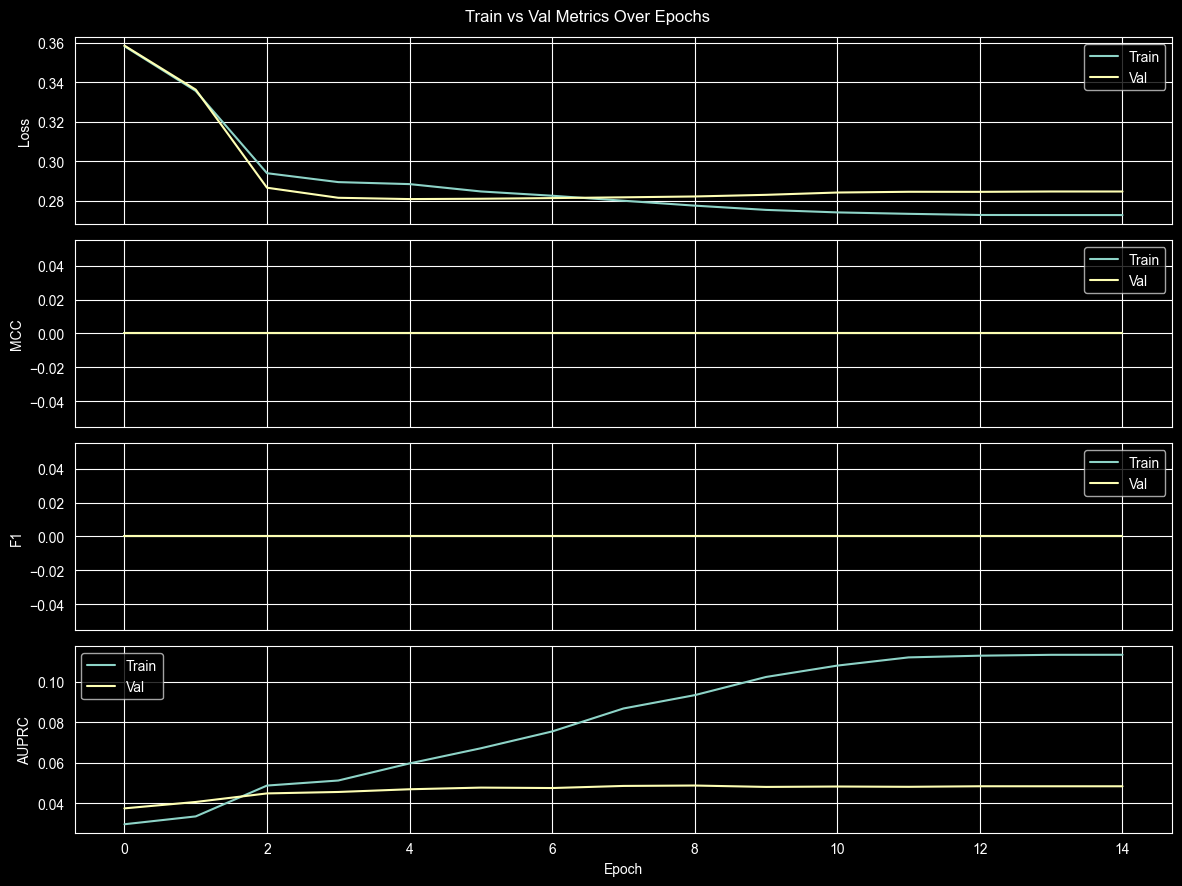

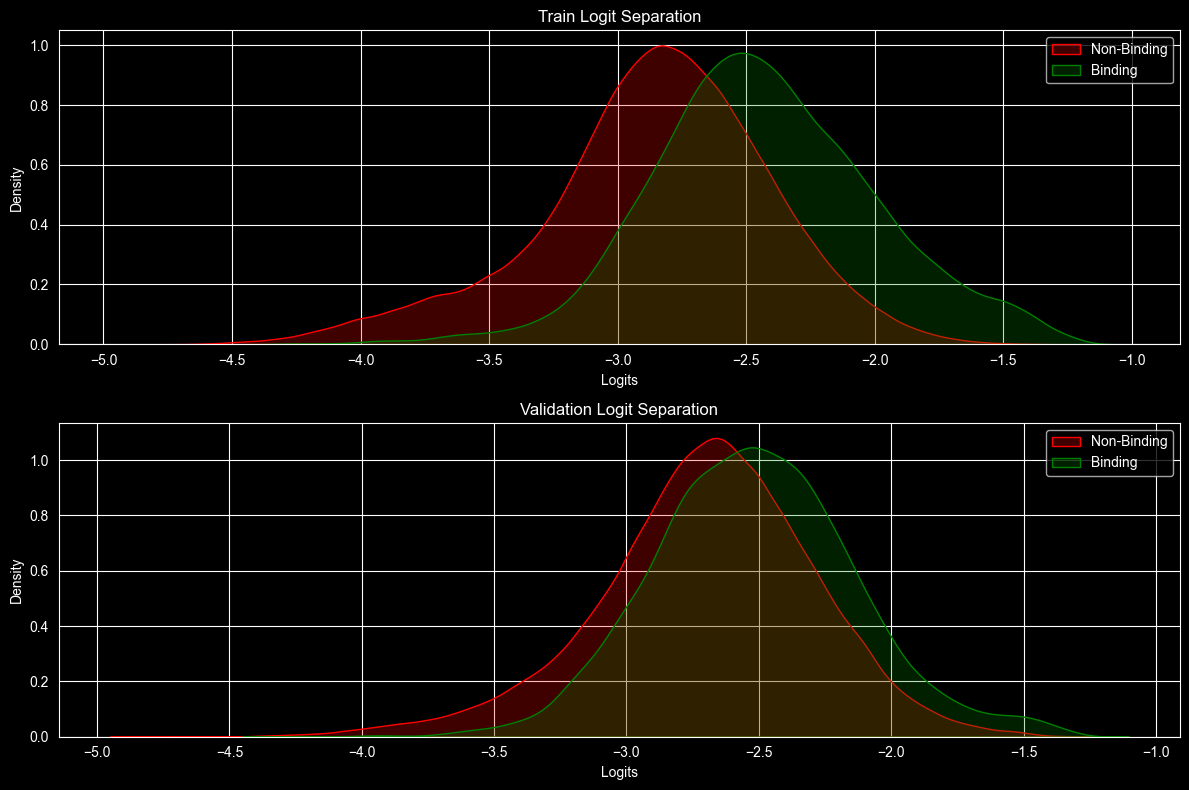

In [22]:
train_results = tester.load_evals('train')
val_results = tester.load_evals('val')
analyze = Analysis(train_results, val_results)

analyze.plot_epoch_scores()
analyze.plot_logit_separation()

(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: title={'center': 'Train Logit Separation'}, xlabel='Logits', ylabel='Density'>,
        <Axes: title={'center': 'Validation Logit Separation'}, xlabel='Logits', ylabel='Density'>],
       dtype=object))

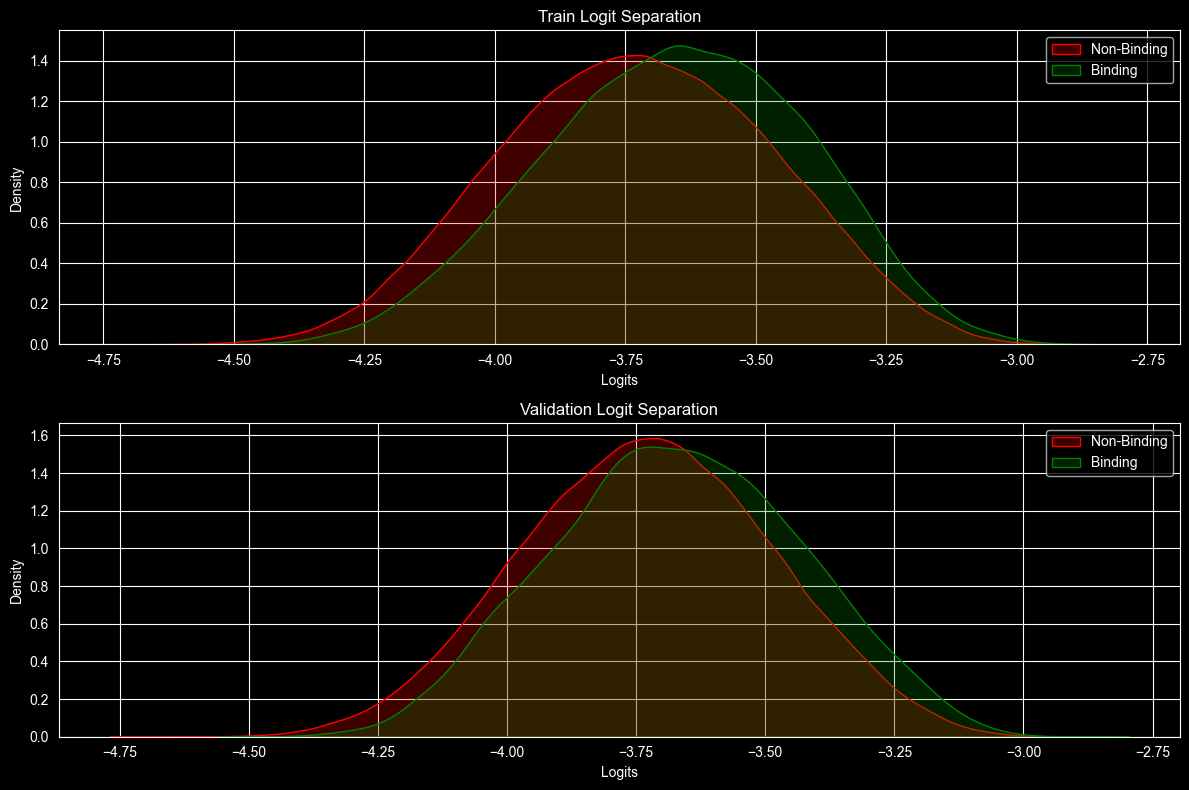

In [23]:
analyze.plot_logit_separation(0)

(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: title={'center': 'Train Logit Separation'}, xlabel='Logits', ylabel='Density'>,
        <Axes: title={'center': 'Validation Logit Separation'}, xlabel='Logits', ylabel='Density'>],
       dtype=object))

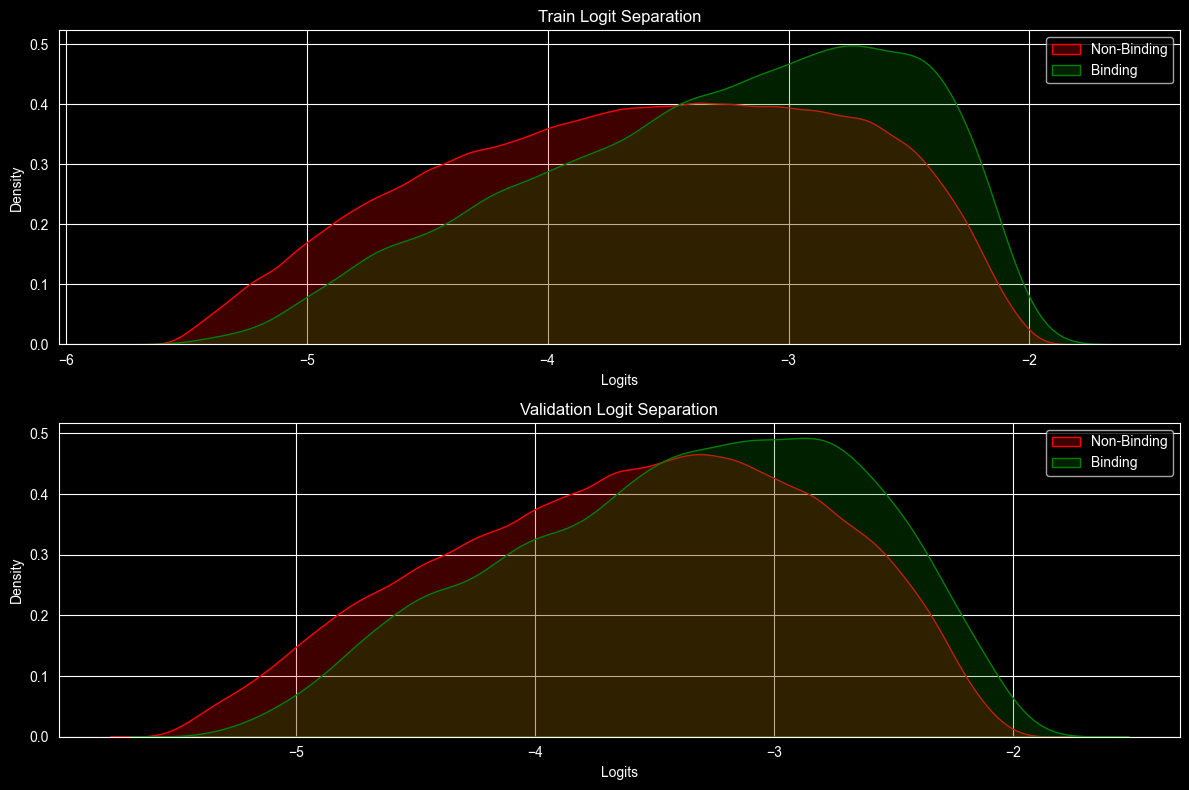

In [24]:
analyze.plot_logit_separation(1)

(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: title={'center': 'Train Logit Separation'}, xlabel='Logits', ylabel='Density'>,
        <Axes: title={'center': 'Validation Logit Separation'}, xlabel='Logits', ylabel='Density'>],
       dtype=object))

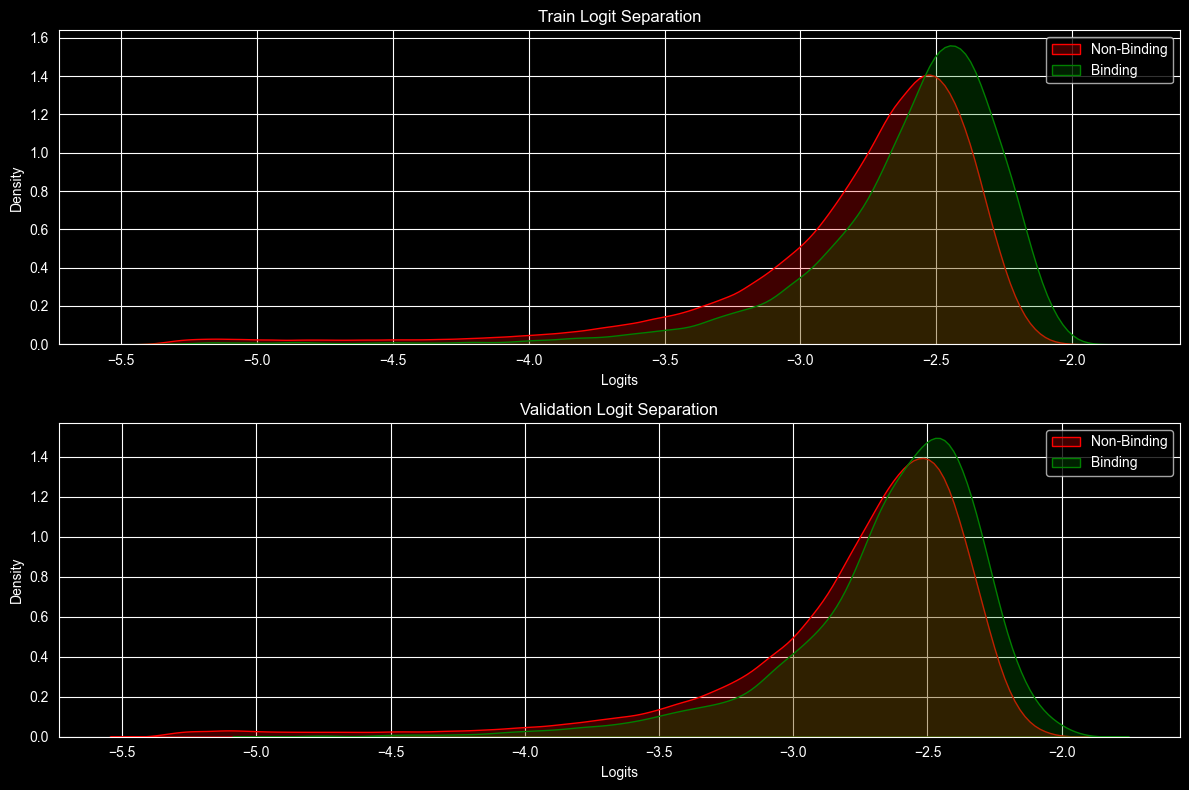

In [25]:
analyze.plot_logit_separation(2)

In [26]:
"""
train_results = tester.evaluate_split("train")
val_results = tester.evaluate_split("val")

print("Train metrics:", train_results["metrics"])
print("Val metrics:", val_results["metrics"])
"""

'\ntrain_results = tester.evaluate_split("train")\nval_results = tester.evaluate_split("val")\n\nprint("Train metrics:", train_results["metrics"])\nprint("Val metrics:", val_results["metrics"])\n'